In [1]:
import os
from typing import TypedDict
import requests
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

api_key = os.getenv("AICREDITS_API_KEY")
base_url = os.getenv("AICREDITS_BASE_URL")

llm = ChatOpenAI(
    model_name="gpt-4o",
    api_key=api_key,
    base_url=base_url,
    temperature=0
)

In [2]:
# =====================================================================
# 2. DEFINING THE STATE SCHEMA
# =====================================================================
class AgentState(TypedDict):
    user_message: str
    user_id: str
    issue_type: str
    step_result: str
    response: str

In [3]:
def categorize_issue(state: AgentState) -> dict:
    """Classifies the inbound customer support message into routing classes."""
    prompt = (
        f"Classify this support request as 'billing' or 'technical'. \n\n"
        f"Message: {state['user_message']}"
    )
    response = llm.invoke([HumanMessage(content=prompt)])
    kind = response.content.strip().lower()
    if "billing" in kind:
        kind = "billing"
    elif "technical" in kind or "tech" in kind:
        kind = "technical"
    
    
    return {"issue_type": kind}

def handle_invoice(state: AgentState) -> dict:
    """Mock Action Node to manage specific invoice tracing requests."""
    
    return {"step_result": f"Invoice details for {state['user_id']} retrieved."}

def handle_refund(state: AgentState) -> dict:
    """Mock Action Node to manage general refund validation queries."""

    return {"step_result": "Refund status checks initiated successfully."}

def handle_login(state: AgentState) -> dict:
    """Mock Action Node to check account authentication status logs."""
    
    return {"step_result": "Password reset credentials link sent successfully."}

def handle_performance(state: AgentState) -> dict:
    """Mock Action Node to measure active system execution diagnostics."""
    
    return {"step_result": "Performance metrics evaluated cleanly."}

def summarize_response(state: AgentState) -> dict:
    """Uses the model to craft a neat customer-facing textual summary."""
    details = state.get("step_result", "")
    prompt = f"Write a concise customer reply based on: {details}"
    response = llm.invoke([HumanMessage(content=prompt)])
    summary = response.content.strip()
    
    
    return {"response": summary}


In [4]:
def top_router(state: AgentState) -> str:
    """Determines whether the customer requires billing or technical assistance."""
    return "billing" if state.get("issue_type") == "billing" else "technical"

def billing_router(state: AgentState) -> str:
    """Sub-branch splitting mechanism for billing tickets."""
    
    if state.get("step_result") and "Invoice details" in state["step_result"]:
        return "refund"
        
    msg = state.get("user_message", "").lower()
    return "invoice" if "invoice" in msg else "refund"

def tech_router(state: AgentState) -> str:
    """Sub-branch splitting mechanism for technical tickets."""
    
    if state.get("step_result") and "Password reset" in state["step_result"]:
        return "performance"
        
    msg = state.get("user_message", "").lower()
    return "login" if "login" in msg else "performance"


In [5]:
# =====================================================================
# 5. GRAPH ORCHESTRATION BUILDER & EDGES WIRING
# =====================================================================
# Pass AgentState structural dictionary layout safely to initialization wrapper
graph_builder = StateGraph(AgentState)

# Register nodes inside the structural blueprint map
graph_builder.add_node("categorize_issue", categorize_issue)
graph_builder.add_node("handle_invoice", handle_invoice)
graph_builder.add_node("handle_refund", handle_refund)
graph_builder.add_node("handle_login", handle_login)
graph_builder.add_node("handle_performance", handle_performance)
graph_builder.add_node("summarize_response", summarize_response)

# Connect start initialization target
graph_builder.add_edge(START, "categorize_issue")


graph_builder.add_conditional_edges(
    "categorize_issue",
    top_router,
    {"billing": "handle_invoice", "technical": "handle_login"}
)

graph_builder.add_conditional_edges(
    "handle_invoice",
    billing_router,
    {"invoice": "handle_invoice", "refund": "handle_refund"}
)

graph_builder.add_conditional_edges(
    "handle_login",
    tech_router,
    {"login": "handle_login", "performance": "handle_performance"}
)

# String based consolidation edges instead of passing raw textbook object calls
graph_builder.add_edge("handle_invoice", "summarize_response")
graph_builder.add_edge("handle_refund", "summarize_response")
graph_builder.add_edge("handle_login", "summarize_response")
graph_builder.add_edge("handle_performance", "summarize_response")

# Finalize exit layout route context safely
graph_builder.add_edge("summarize_response", END)

# Compile framework architecture elements
graph = graph_builder.compile()
print(" Architecture Compiled Perfectly! Ready for operation verification.\n")



 Architecture Compiled Perfectly! Ready for operation verification.



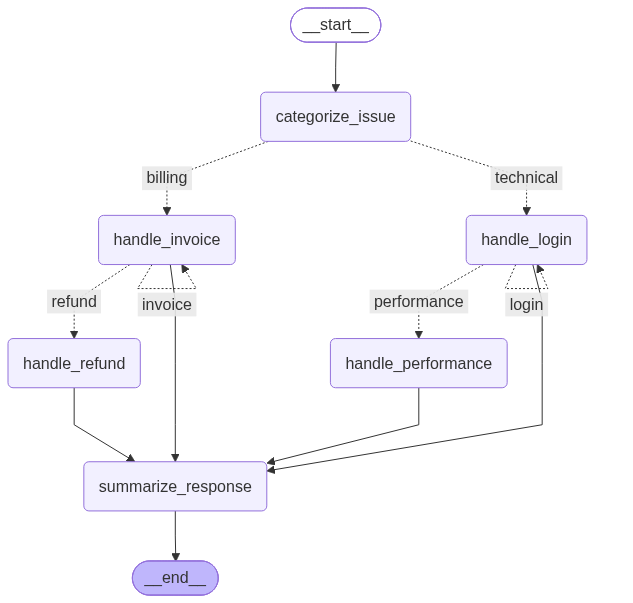

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# =====================================================================
# 6. RUN THE AUTOMATION ENGINE
# =====================================================================
initial_state = {
    "user_message": "Hi, I need help with my invoice and possibly a refund.",
    "user_id": "U1234"
}

# Fixed from legacy .run() wrapper to modern structural object execution (.invoke)
result = graph.invoke(initial_state)

print("--- Final Agent Context Execution Output ---")
print(f"Classification:   {result.get('issue_type')}")
print(f"Step Diagnostic:  {result.get('step_result')}")
print(f"Final AI Summary: {result.get('response')}")


--- Final Agent Context Execution Output ---
Classification:   billing
Step Diagnostic:  Refund status checks initiated successfully.
Final AI Summary: Thank you for confirming. Could you please provide an estimated timeline for when I can expect the refund?
